# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** Sankalp Tiwari  
**Register Number:** AP24110010356  
**Date:** August 24, 2026  

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [2]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [3]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [4]:
# 1. Create missing values in the `tip` column (5 random rows)
tips_missing_tip = tips.copy()
np.random.seed(42)
missing_idx_tip = np.random.choice(tips_missing_tip.index, size=5, replace=False)
tips_missing_tip.loc[missing_idx_tip, 'tip'] = np.nan

print("Missing values:", tips_missing_tip['tip'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing_tip['tip'].isna().sum() / len(tips_missing_tip)))

# 2. Fill using the median `tip` grouped by `time` (Lunch/Dinner)
time_medians = tips_missing_tip.groupby('time')['tip'].transform('median')
tips_tip_filled = tips_missing_tip.copy()
tips_tip_filled['tip'] = tips_missing_tip['tip'].fillna(time_medians)

print("Remaining missing:", tips_tip_filled['tip'].isna().sum())
tips_tip_filled[['tip', 'time']].head()

# 3. Justification: Lunch and Dinner tend to have systematically different tipping
# behavior (dinner bills/tips are usually higher than lunch), so filling with the
# time-specific median preserves that real difference instead of flattening both
# meal types to one global number, and the median is also more robust to any
# outlier tips within each group than a mean would be.


Missing values: 5
Percentage missing: 2.0%
Remaining missing: 0


,tip,time
0,1.01,Dinner
1,1.66,Dinner
2,3.50,Dinner
3,3.31,Dinner
4,3.61,Dinner


**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:*
Group-wise mean/median fill is better than a single global fill whenever
subgroups in the data differ systematically. For example, if we filled missing
`total_bill` values with the overall mean, a Saturday dinner bill would likely be
underestimated (since dinners/weekends run higher) while a weekday lunch bill would
be overestimated. Filling within each day's own mean/median keeps these real,
meaningful differences intact instead of flattening every missing value to the same
number, which produces more realistic imputed values and avoids distorting patterns
a later model might try to learn.


## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [5]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [6]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


,day,day_Thur,day_Fri,day_Sat,day_Sun
0,Sun,False,False,False,True
1,Sun,False,False,False,True
2,Sun,False,False,False,True
3,Sun,False,False,False,True
4,Sun,False,False,False,True


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:*


In [7]:
# Prediction: `time` has only 2 categories (Lunch, Dinner) with no natural order
# between them, so I'll use LABEL ENCODING (0/1), the same way `sex` and `smoker`
# were handled above. With only two categories, one-hot encoding would just add a
# second column that is the exact mirror image of the first (redundant information),
# so a single 0/1 label column already captures everything needed.

tips_enc['time_encoded'] = tips_enc['time'].map({'Lunch': 0, 'Dinner': 1})
tips_enc[['time', 'time_encoded']].head()


,time,time_encoded
0,Dinner,1
1,Dinner,1
2,Dinner,1
3,Dinner,1
4,Dinner,1


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*
Label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 is misleading because it
imposes a false numeric ordering and false distances between categories that don't
actually exist in reality — the model may interpret "Sun" (3) as being "greater than"
or "3x" a "Thur" (0), or assume Sat and Sun are "closer" to each other than Thur and
Sun are, purely because of how the numbers happen to compare. Since days of the week
have no inherent rank in this context, one-hot encoding is the honest representation:
it lets the model treat each day as a separate, unordered category.


## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [8]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [9]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:*

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [10]:
# Prediction: after standardizing, the mean of `total_bill_standardized` should be
# approximately 0, and the standard deviation should be approximately 1 — that is
# exactly what standardization is defined to produce (subtracting the mean centers
# the data at 0, and dividing by the std rescales the spread to 1).

print("Mean:", tips_enc['total_bill_standardized'].mean())
print("Std:", tips_enc['total_bill_standardized'].std())

# Apply min-max scaling to the `size` column
tips_enc['size_scaled'] = min_max_scale(tips_enc['size'])
tips_enc[['size', 'size_scaled']].describe()


Mean: -6.028875031263658e-17
Std: 1.0


,size,size_scaled
count,244.000,244.000
mean,2.570,0.314
std,0.951,0.190
min,1.000,0.000
25%,2.000,0.200
50%,2.000,0.200
75%,3.000,0.400
max,6.000,1.000


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:*
Min-max scaling squeezes every value into a fixed [0, 1] range based on the
column's own min and max, while standardization centers the data at mean 0 with a
standard deviation of 1, with no fixed upper or lower bound. Min-max scaling is very
sensitive to outliers — a single extreme value stretches the whole range, squashing
the rest of the data into a tiny sliver near 0. Standardization is somewhat more
robust since it's based on mean/std rather than min/max, though a big outlier will
still inflate the standard deviation and shrink everything else toward 0. I'd prefer
standardization for algorithms that assume roughly normal/centered data (e.g. linear
regression, logistic regression, PCA) or when outliers are present, and min-max
scaling when I need values in a strict bounded range (e.g. pixel values or certain
neural network inputs) and the data is relatively outlier-free.


## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [11]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


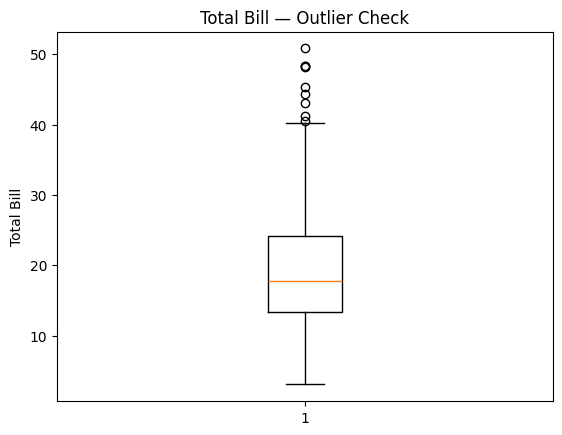

In [12]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [13]:
# 1. IQR outlier check on the `tip` column
Q1_tip = tips['tip'].quantile(0.25)
Q3_tip = tips['tip'].quantile(0.75)
IQR_tip = Q3_tip - Q1_tip

lower_bound_tip = Q1_tip - 1.5 * IQR_tip
upper_bound_tip = Q3_tip + 1.5 * IQR_tip

outliers_tip = tips[(tips['tip'] < lower_bound_tip) | (tips['tip'] > upper_bound_tip)]
print(f"Bounds: [{lower_bound_tip:.2f}, {upper_bound_tip:.2f}]")
print(f"Number of outliers: {len(outliers_tip)}")
outliers_tip[['tip', 'day', 'size']]

# 2. Cap (winsorize) instead of dropping
tips_capped = tips.copy()
tips_capped['tip'] = tips_capped['tip'].clip(lower=lower_bound_tip, upper=upper_bound_tip)

print("Max tip before capping:", tips['tip'].max())
print("Max tip after capping:", tips_capped['tip'].max())
print("Rows remaining after capping:", len(tips_capped), "(same as original:", len(tips), ")")


Bounds: [-0.34, 5.91]
Number of outliers: 9
Max tip before capping: 10.0
Max tip after capping: 5.90625
Rows remaining after capping: 244 (same as original: 244 )


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:*
Capping is often preferable to dropping because it keeps the row (and every other
feature value in that row) instead of discarding potentially useful information from
the rest of the observation, and it preserves the dataset's size, which matters when
data is limited. It also reduces the extreme value's influence on the model without
pretending the observation never happened. Dropping is the better choice when the
outlier is clearly a data-entry error or a measurement mistake rather than a genuine
(if unusual) observation, or when only a handful of such rows exist so removing them
won't meaningfully shrink the dataset or introduce bias.


## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [14]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [15]:
# 1. Redo the split with test_size=0.3
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3, random_state=42)

print("Train shape:", X_train2.shape)
print("Test shape:", X_test2.shape)
print("Rows in test set now:", X_test2.shape[0])

# 2. Why random_state=42?
# We fix random_state so the "random" split is actually reproducible: every time this
# code runs, the exact same rows land in train vs. test. That matters because it lets
# us (and anyone re-running our notebook) get identical, comparable results when
# testing or debugging a model. Without a fixed random_state, sklearn would draw a
# different random shuffle each run, so the train/test rows -- and therefore any
# reported accuracy or other metrics -- would shift slightly between runs, making
# results hard to reproduce, compare, or debug.


Train shape: (170, 4)
Test shape: (74, 4)
Rows in test set now: 74


**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:*
We split before the model ever sees the test set so the test set stays a genuinely
unseen, unbiased measure of how well the model generalizes to new data. If we trained
on all the data, including what we'd call the "test set," the model could simply
memorize those examples, and its performance on them would look artificially good --
that wouldn't tell us anything about how it performs on real, unseen data, which is
the whole point of evaluating a model in the first place.


# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [16]:
from google.colab import files
uploaded = files.upload()


Saving images.png to images.png


In [17]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


Original pixel range: 0 - 170
Original dtype: uint8
Normalized pixel range: 0.0 - 0.6666666666666666
Normalized dtype: float64


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [18]:
# 1. Normalize all uploaded images and store each normalized array in a list
normalized_images = []
records = []

for fname in filenames:
    arr = np.array(Image.open(fname))
    norm = arr / 255.0
    normalized_images.append(norm)
    records.append({
        'filename': fname,
        'min_pixel_before': arr.min(),
        'max_pixel_before': arr.max(),
        'min_pixel_after': norm.min(),
        'max_pixel_after': norm.max()
    })

# 2. Build a DataFrame to confirm normalization worked correctly across all images
normalization_check = pd.DataFrame(records)
normalization_check

# NOTE: this cell depends on `filenames`/`uploaded` from the Colab file-upload widget
# above (Step 1 demo), so it needs to be run in Colab after uploading your Week 2
# mini-project images -- it can't execute here since no images were uploaded.


,filename,min_pixel_before,max_pixel_before,min_pixel_after,max_pixel_after
0,images.png,0,170,0.0,0.667


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [19]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


Original shape: (300, 300)
Resized shape: (128, 128)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [20]:
# Resize all uploaded images to (128, 128), normalize to 0-1, and confirm
# every resulting array has the exact same shape
resized_records = []
resized_normalized_images = []

for fname in filenames:
    img = Image.open(fname)
    img_resized = img.resize(target_size)
    arr_resized = np.array(img_resized) / 255.0
    resized_normalized_images.append(arr_resized)
    resized_records.append({'filename': fname, 'shape': arr_resized.shape})

resized_check = pd.DataFrame(resized_records)
print("All shapes identical:", resized_check['shape'].nunique() == 1)
resized_check

# NOTE: like the cell above, this depends on `filenames` from the Colab upload
# widget, so run it in Colab after uploading your images.


All shapes identical: True


,filename,shape
0,images.png,"(128, 128)"


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

*Your answer:*
Every image fed into a model must have the exact same shape because the model's
input layer -- and every matrix operation that follows it -- is built to expect a
fixed-size input. A fully-connected layer expects a vector of one specific length,
and even convolutional networks eventually flatten to fixed-size fully-connected
layers, so a different spatial size breaks that assumption. Practically, you also
can't stack images of different sizes into one array/tensor to feed the model as a
batch -- attempting to do so, or passing a mismatched shape into the first layer,
would simply raise a shape-mismatch error and the model wouldn't run at all.


# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [21]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [22]:
my_raw_text = "Wow!!! Machine Learning, AI, and Data Science are SO cool in 2026 -- I study them every single day."

my_cleaned = my_raw_text.lower()
my_cleaned = re.sub(r'[^a-z0-9\s]', '', my_cleaned)  # remove punctuation
my_tokens = my_cleaned.split()

print("Before:", my_raw_text)
print("After:", my_tokens)


Before: Wow!!! Machine Learning, AI, and Data Science are SO cool in 2026 -- I study them every single day.
After: ['wow', 'machine', 'learning', 'ai', 'and', 'data', 'science', 'are', 'so', 'cool', 'in', '2026', 'i', 'study', 'them', 'every', 'single', 'day']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [23]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'amazing': 0, 'and': 1, 'are': 2, 'day': 3, 'every': 4, 'i': 5, 'numpy': 6, 'pandas': 7, 'scikitlearn': 8, 'tools': 9, 'use': 10}
Original tokens: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']
Encoded as IDs:   [6, 7, 1, 8, 2, 0, 9, 5, 10, 6, 4, 3]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [24]:
# 1. Build a word_to_id mapping for the tokens from Step 1
my_vocabulary = sorted(set(my_tokens))
my_word_to_id = {word: idx for idx, word in enumerate(my_vocabulary)}

# 2. Encode tokens into a list of numeric IDs
my_encoded_tokens = [my_word_to_id[word] for word in my_tokens]

print("Word to ID mapping:", my_word_to_id)
print("Original tokens:", my_tokens)
print("Encoded as IDs:  ", my_encoded_tokens)

# 3. DataFrame of the full mapping, sorted by id
word_id_df = pd.DataFrame(list(my_word_to_id.items()), columns=['word', 'id']).sort_values('id').reset_index(drop=True)
word_id_df


Word to ID mapping: {'2026': 0, 'ai': 1, 'and': 2, 'are': 3, 'cool': 4, 'data': 5, 'day': 6, 'every': 7, 'i': 8, 'in': 9, 'learning': 10, 'machine': 11, 'science': 12, 'single': 13, 'so': 14, 'study': 15, 'them': 16, 'wow': 17}
Original tokens: ['wow', 'machine', 'learning', 'ai', 'and', 'data', 'science', 'are', 'so', 'cool', 'in', '2026', 'i', 'study', 'them', 'every', 'single', 'day']
Encoded as IDs:   [17, 11, 10, 1, 2, 5, 12, 3, 14, 4, 9, 0, 8, 15, 16, 7, 13, 6]


,word,id
0,2026,0
1,ai,1
2,and,2
3,are,3
4,cool,4
5,data,5
6,day,6
7,every,7
8,i,8
9,in,9


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:*
Yes, the same "misleading order" problem applies here. Assigning IDs alphabetically
(e.g. "ai"=0, "cool"=1, "data"=2, ...) implies a numeric relationship between words
that doesn't actually exist -- a model could end up treating "id 4" as somehow
"twice" "id 2," or assume words with closer IDs are more similar in meaning, when the
ID is really just an arbitrary index produced by sorting the vocabulary alphabetically.
This is exactly why real NLP pipelines don't feed raw word-to-ID integers directly
into most models -- they use one-hot vectors, learned embeddings, or other
representations instead, treating the ID purely as a lookup key rather than a
meaningful number.


# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.
---

### My Answers

**1. Order of preprocessing steps, and why:**
1. **Handle missing data first** -- later steps (encoding, scaling, outlier stats)
   can break or be skewed by NaNs, so the data needs to be complete first.
2. **Encode categorical variables** -- converts everything to a fully numeric table,
   which every later numeric step (outlier detection, scaling) assumes.
3. **Detect and handle outliers** -- done before scaling because scaling statistics
   (min/max, mean/std) are themselves distorted by extreme outliers, so it's better
   to clean them up first.
4. **Scale/normalize numeric features** -- last of the "cleaning" steps, once the
   values are complete, numeric, and outlier-checked, so the resulting scale reflects
   the real, intended distribution.
5. **Split into train/test** -- in this lab it's the final step; in stricter practice,
   the split is often done right after cleaning/encoding, and outlier bounds/scaling
   parameters are then *fit on the training set only* and applied to the test set, to
   avoid leaking information about the test set into training.

**2. Why preprocessing is "data work," not something a model does automatically:**
Preprocessing requires human judgment and domain knowledge that a model can't supply
on its own -- deciding whether missing data is random or systematic, whether a
category has a natural order, which scaling method fits the algorithm being used, and
whether an extreme value is a genuine observation or a data-entry error, are all
decisions that need understanding of the data and the problem. A model only learns
patterns from the numbers it's handed; it has no way to decide what the "right"
numbers should have been in the first place.

**3. Images vs. text preprocessing -- what's conceptually similar:**
Both are about turning a raw, real-world signal into a consistent numeric form a
model can operate on. Normalizing pixels rescales values that already range 0-255
into a fixed 0-1 range so every image contributes comparably regardless of original
brightness. Encoding words as IDs converts arbitrary symbols (words) into integers so
text can be represented numerically at all. The difference is that pixel
normalization preserves a meaningful magnitude relationship (0.5 really is "half as
bright" as 1.0), while word-to-ID encoding doesn't preserve any meaningful numeric
relationship -- the ID is just a lookup index, the same "misleading order" issue
raised in Part 2 and Mini Project B's reflection.

**4. Concept I still feel unsure about:**
I'd like more clarity on exactly *when* to fit scalers/encoders relative to the
train/test split -- whether it's ever acceptable to fit on the full dataset before
splitting, versus always fitting only on the training set and then applying that same
transformation to the test set to avoid leaking test-set information into training. A
concrete example of the accuracy difference caused by "leaky" scaling vs. correct
scaling would make the practical risk clearer to me.
